In [2]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
import numpy as np
import os
from torch.utils.data.dataset import Dataset
from torchvision import transforms
import tqdm
from PIL import Image

from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            # why kernel size 3 and padding1?
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            # saves memory
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)
    
class DownSample(nn.Module):
    def __init__(self,in_channels, out_channels):
        super().__init__()
        self.conv= DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)
        # why down and p? skip connectons
        return down, p 

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # concat skip connection x2 with x1
        x = torch.cat([x1,x2], dim=1)
        return self.conv(x)

In [4]:
class UNET(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        # third conv at end
        # kernell size 1 why?
        self.out = nn.Conv2d(64, num_classes, kernel_size=1)


    def forward(self, x):  
        """nested forward, run the forward of down_convolution_1, which is class DownSample forward method
        """
        down1, p1 = self.down_convolution_1(x)
        down2, p2 = self.down_convolution_2(p1)
        down3, p3 = self.down_convolution_3(p2)
        down4, p4 = self.down_convolution_4(p3)
        b = self.bottleneck(p4)
        up1 = self.up_convolution_1(b, down4)
        up2 = self.up_convolution_2(up1, down3)
        up3 = self.up_convolution_3(up2, down2)
        up4 = self.up_convolution_4(up3, down1)
        
        # call last layer
        out = self.out(up4)
        return out


In [5]:



class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        re_size = (128, 128)

        # resize and to tensor for the image
        self.img_transform = transforms.Compose([
            transforms.Resize((re_size)),
            transforms.ToTensor()
        ])

        # for the mask,
        self.mask_transform = transforms.Compose([
            transforms.Resize(re_size, interpolation=transforms.InterpolationMode.NEAREST),
            transforms.PILToTensor() 
        ])
    
    def __getitem__(self, idx):
        img, mask = self.dataset[idx] 
        
        img = img.convert("RGB")
        
        # 2. Apply our transforms
        img = self.img_transform(img)
        mask = self.mask_transform(mask)
        
        # 3. Format mask for Binary Cross Entropy
        mask = torch.where(mask == 1, 1.0, 0.0)
        
        return img, mask

    def __len__(self):
        return len(self.dataset)

## dataset

In [6]:
raw_train = OxfordIIITPet(root="./data", split="trainval", target_types="segmentation", download=True)
raw_val = OxfordIIITPet(root="./data", split="test", target_types="segmentation", download=True)

train_ds = CustomDataset(raw_train)
val_ds = CustomDataset(raw_val)


(394, 500)


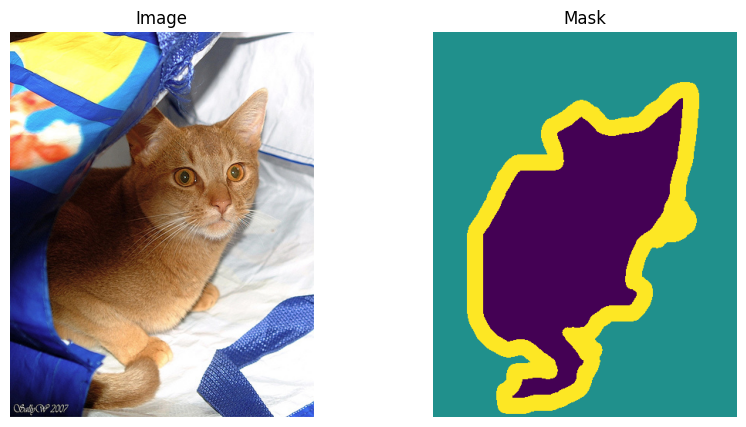

In [7]:
raw_train = OxfordIIITPet(root="./data", split="trainval", target_types="segmentation", download=True)
    # raw_val = OxfordIIITPet(root="./data", split="test", target_types="segmentation", download=True)
img, mask = raw_train[0]
print(img.size)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img)
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(mask)
ax[1].set_title("Mask")
ax[1].axis("off")

plt.show()

torch.Size([3, 128, 128])


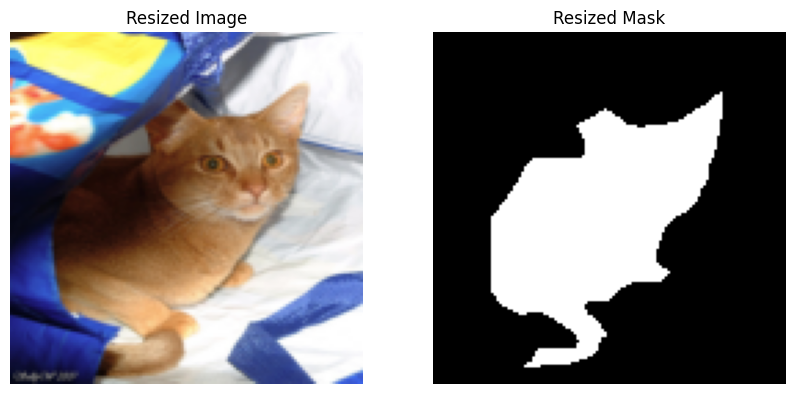

In [8]:
train_ds = CustomDataset(raw_train)

img, mask = train_ds[0]
print(img.shape)
img_np = img.permute(1, 2, 0).numpy()
mask_np = mask.squeeze(0).numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img_np)
ax[0].set_title("Resized Image")
ax[0].axis("off")

ax[1].imshow(mask_np, cmap="gray")
ax[1].set_title("Resized Mask")
ax[1].axis("off")

plt.show()

In [9]:
if __name__ == "__main__":
    
    LEARINING_RATE = 3e-4
    BATCH_SIZE = 16
    NUM_EPOCHS = 5
    
    MODEL_SAVE_PATH = "./models/unet.pth"
    # MODEL_SAVE_PATH = MODEL_SAVE_PATH
    
    if torch.cuda.is_available():
        device = "cuda"
    elif torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    print(f"Using {device} device")

    raw_train = OxfordIIITPet(root="./data", split="trainval", target_types="segmentation", download=True)
    raw_val = OxfordIIITPet(root="./data", split="test", target_types="segmentation", download=True)

    train_ds = CustomDataset(raw_train)
    val_ds = CustomDataset(raw_val)
    
    # random seed for train_laoder, liek random seed
    generator = torch.Generator().manual_seed(1)
    
    # batch, shuffle ...
    # returns batch, channel, h, w
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator)

    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = UNET(in_channels=3, num_classes=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARINING_RATE)
    loss_fn = nn.BCEWithLogitsLoss()
    if os.path.exists("./models/unet.pth"):
        print("Model already exists. Skipping training.")
        model.load_state_dict(torch.load("./models/unet.pth"))
    else: 
        print("Model does not exist. Starting training.")
        for epoch in tqdm.tqdm(range(NUM_EPOCHS)):
            # Training phase
            model.train()
            train_running_loss = 0.0
            # batch,(channel) image, mask
            for batch, (images, masks) in (enumerate(train_loader)):
                # move to device, m5 chip
                images = images.to(device)
                masks = masks.to(device)

                optimizer.zero_grad()
                y_pred = model(images)
                loss = loss_fn(y_pred, masks)
                
                loss.backward()
                optimizer.step()
                # avg over batches-> sum up the losses/batch size, .item() turn tensor to scalar
                train_running_loss += loss.item()
            
            # len(train_loader) = batch size
            train_loss = train_running_loss / len(train_loader)
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Training Loss: {train_loss:.4f}")

            model.eval()
            val_running_loss = 0.0

            # dont change grad, save computation
            with torch.no_grad():
                for batch, (images, masks) in tqdm.tqdm(enumerate(val_loader)):
                    images = images.to(device)
                    masks = masks.to(device)

                    y_pred = model(images)
                    loss = loss_fn(y_pred, masks)
                    val_running_loss += loss.item()
            
            val_loss = val_running_loss / len(val_loader)
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Validation Loss: {val_loss:.4f}")
            
            torch.save(model.state_dict(), MODEL_SAVE_PATH)

Using mps device
Model already exists. Skipping training.


In [64]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
from zennit.composites import EpsilonGammaBox
from zennit.composites import EpsilonPlusFlat
from zennit.attribution import Gradient
from zennit.image import imgify
from zennit.canonizers import SequentialMergeBatchNorm


def validate_image(model_path, val_dataset, device, image_index=None):
    if image_index is None:
        image_index = random.randint(0, len(val_dataset) - 1)
        
    img_tensor, true_mask_tensor = val_dataset[image_index]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad_()
    
    # Initialize and load model
    model = UNET(in_channels=3, num_classes=1).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    
    # Forward Pass
    with torch.no_grad():
        loss_fn = nn.BCEWithLogitsLoss()
        raw_output = model(input_tensor)
        probabilities = torch.sigmoid(raw_output)
        predicted_mask = (probabilities > 0.5).float()
        loss = loss_fn(raw_output, true_mask_tensor.unsqueeze(0).to(device))
        print(f"loss: {loss}")

    # zennit for both classes (segmentation with 2 classes here)
    mask_A = predicted_mask
    # negative mask
    mask_B = 1.0 - predicted_mask

    composite = EpsilonGammaBox(
        low=0.0,
        high=1.0,
        epsilon= 0.1,
        gamma=0.1
        # canonizers=[SequentialMergeBatchNorm()]    
    )
    # composite = EpsilonPlusFlat()
    
    # turn unet into invariant model
    with Gradient(model=model, composite=composite) as attributor:
        # Calculate full Foreground Relevance
        _, attr_A = attributor(input_tensor, mask_A)
        # Calculate full Background Relevance
        _, attr_B = attributor(input_tensor, mask_B)
        
        # Combine them for the final total attribution
        attribution = attr_A + attr_B

  
    display_image = img_tensor.cpu().detach().permute(1, 2, 0)
    true_mask = true_mask_tensor.squeeze().cpu()      
    predicted_mask_sq = predicted_mask.squeeze().cpu()
    
    fig, axes = plt.subplots(2, 2, figsize=(4, 4))
    
    axes[0][0].imshow(display_image)
    axes[0][0].set_title(f"Input Image #{image_index}")
    axes[0][0].axis('off')
    
    axes[0][1].imshow(true_mask, cmap='gray')
    axes[0][1].set_title("Ground Truth")
    axes[0][1].axis('off')
    
    axes[1][0].imshow(predicted_mask_sq, cmap='gray')
    axes[1][0].set_title("Full Prediction Mask")
    axes[1][0].axis('off')
    
    # relevance = attribution.sum(1).cpu().detach()
    # zennit imgify
    # # img = imgify(relevance,symmetric=True,cmap="bwr")
    # img = imgify(relevance,symmetric=True,cmap="coldnhot")
    # axes[1][1].imshow(img)
    # axes[1][1].set_title("heatmap")
    # axes[1][1].axis('off')
  
    # attribution (1,3,128,128) -> squeeze: (3,128,128) -> sum0: (128,128)
    relevance = attribution.squeeze().sum(dim=0).cpu().detach()
    b = 10 * ((torch.abs(relevance)**3.0).mean()**(1.0/3)).item()
    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)   
    axes[1][1].imshow(relevance, cmap=my_cmap, vmin=-b, vmax=b, interpolation='nearest')
    axes[1][1].set_title("LRP Heatmap")
    axes[1][1].axis('off')

    
    plt.tight_layout()
    plt.show()

    return fig

mps
loss: 0.06493673473596573


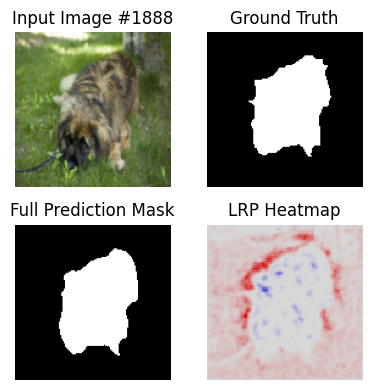

In [65]:

if __name__ == "__main__":
    # device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    
    
    print(device)
    MODEL_PATH = "./models/unet.pth"
    # 2900 2767 1888
    fig = validate_image(MODEL_PATH, val_ds, device, 1888)
    

In [37]:
fig.savefig(
    "./1888_b.pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

In [46]:
import zennit.canonizers

# This will print a list of all classes, functions, and variables in the module
print([name for name in dir(zennit.canonizers) if not name.startswith('_')])

['ABCMeta', 'AttributeCanonizer', 'BatchNorm', 'Canonizer', 'CompositeCanonizer', 'ConvolutionTranspose', 'Linear', 'MergeBatchNorm', 'NamedMergeBatchNorm', 'SequentialMergeBatchNorm', 'abstractmethod', 'collect_leaves', 'torch']
